In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


Exo 2 

a) Differential equations

In [2]:
mu_m  = 0.2    # h-1, max specific growth rate
Ks    = 0.50   # g/L, Monod constant
Ki    = 50.0   # g/L, inhibition constant (uncompetitive)
Yxs   = 0.3    # g-cells / g-glucose
qp    = 0.08   # g-product / g-cell / h

V0    = 200.0  # L, initial volume
X0    = 30.0   # g/L, initial cell concentration
S0_ic = 0.0    # g/L, initial substrate concentration (no glucose at t=0)
P0_ic = 0.0    # g/L, initial product concentration

V_max = 800.0  # L, tank capacity
V_rem = 600.0  # L, volume removed at end of each cycle
f0    = 50.0   # L/h, feed flow rate
S_feed = 100.0 # g/L, glucose concentration in feed

n_cycles = 10  # number of cycles to simulate

### Growth rate with substrate inhibition

Since glucose acts as a substrate inhibitor, the growth rate is written as

$$
\boxed{
\mu = \frac{\mu_m S}{K_S + S + \frac{S^2}{K_I}}
}
$$

where $\mu_m$ is the maximum specific growth rate, $K_S$ is the Monod constant, and $K_I$ is the inhibition constant.



In [3]:
def mu(S):
    return mu_m * S / (Ks + S * (1 + S / Ki))

## Derivation of the fed-batch differential equations

In Exercise 2, the reactor is operated in fed-batch mode. Therefore, the volume is not constant because glucose solution is continuously added with flow rate $F$. Since there is no outlet during the filling phase, the volume balance is

$$
\frac{dV}{dt} = F
$$

with the initial condition

$$
V(0) = V_0 = 200~\mathrm{L}
$$

---

### 1. Biomass balance

The general biomass mass balance is

$$
\frac{d(XV)}{dt} = \text{in} - \text{out} + \text{growth}
$$

There are no cells in the feed and no outlet during the filling phase, so only growth contributes:

$$
\frac{d(XV)}{dt} = \mu X V
$$

Using the product rule,

$$
\frac{d(XV)}{dt} = V\frac{dX}{dt} + X\frac{dV}{dt}
$$

Substituting $dV/dt = F$:

$$
V\frac{dX}{dt} + XF = \mu X V
$$

Dividing by $V$, the biomass differential equation becomes

$$
\boxed{\frac{dX}{dt} = \mu X - \frac{F}{V}X}
$$

with

$$
X(0) = 30~\mathrm{g/L}
$$

---

### 2. Substrate balance

The substrate balance is

$$
\frac{d(SV)}{dt} = \text{substrate in} - \text{substrate consumed}
$$

The substrate enters with concentration $S_f$, so the input term is $F S_f$. Substrate is consumed for biomass formation. Neglecting maintenance,

$$
r_S = \frac{\mu X}{Y_{X/S}}
$$

Thus,

$$
\frac{d(SV)}{dt} = F S_f - \frac{\mu X V}{Y_{X/S}}
$$

Using the product rule,

$$
V\frac{dS}{dt} + S\frac{dV}{dt} = F S_f - \frac{\mu X V}{Y_{X/S}}
$$

Substituting $dV/dt = F$:

$$
V\frac{dS}{dt} + SF = F S_f - \frac{\mu X V}{Y_{X/S}}
$$

Dividing by $V$, the substrate differential equation becomes

$$
\boxed{\frac{dS}{dt} = \frac{F}{V}(S_f - S) - \frac{\mu X}{Y_{X/S}}}
$$

with

$$
S(0) = 0~\mathrm{g/L}
$$

---

### 3. Product balance

The product balance is

$$
\frac{d(PV)}{dt} = \text{product formation}
$$

The product is formed by the cells with specific production rate $q_p$, so

$$
\frac{d(PV)}{dt} = q_p X V
$$

Using the product rule,

$$
V\frac{dP}{dt} + P\frac{dV}{dt} = q_p X V
$$

Substituting $dV/dt = F$:

$$
V\frac{dP}{dt} + PF = q_p X V
$$

Dividing by $V$, the product differential equation becomes

$$
\boxed{\frac{dP}{dt} = q_p X - \frac{F}{V}P}
$$

with

$$
P(0) = 0~\mathrm{g/L}
$$

---

### Final ODE system

The system solved numerically is therefore

$$
\boxed{\frac{dV}{dt} = F}
$$

$$
\boxed{\frac{dX}{dt} = \mu X - \frac{F}{V}X}
$$

$$
\boxed{\frac{dS}{dt} = \frac{F}{V}(S_f - S) - \frac{\mu X}{Y_{X/S}}}
$$

$$
\boxed{\frac{dP}{dt} = q_p X - \frac{F}{V}P}
$$

with

$$
\mu = \frac{\mu_m S}{K_S + S + \frac{S^2}{K_I}}
$$

The initial conditions are

$$
S(0) = 0, \quad X(0) = 30, \quad P(0) = 0, \quad V(0) = 200
$$

In [4]:
def fed_batch_odes(t, y):
    S, X, P, V = y
    S = max(S, 0.0)
    X = max(X, 0.0)
    P = max(P, 0.0)

    D = f0 / V                # dilution due to feed
    mu_val = mu(S)

    dS = D * (S_feed - S) - (mu_val / Yxs) * X
    dX = mu_val * X - D * X
    dP = qp * X - D * P
    dV = f0
    return [dS, dX, dP, dV]

b) Cycle time

In [5]:
V_start = V0               
t_cycle = (V_max - V_start) / f0   
print(f"Part (b): Cycle time = {t_cycle:.1f} h")

Part (b): Cycle time = 12.0 h


c) 10-cycle simulation


Part (c): Total product removed over 10 cycles = 136.8731 kg  (136873.1 g)


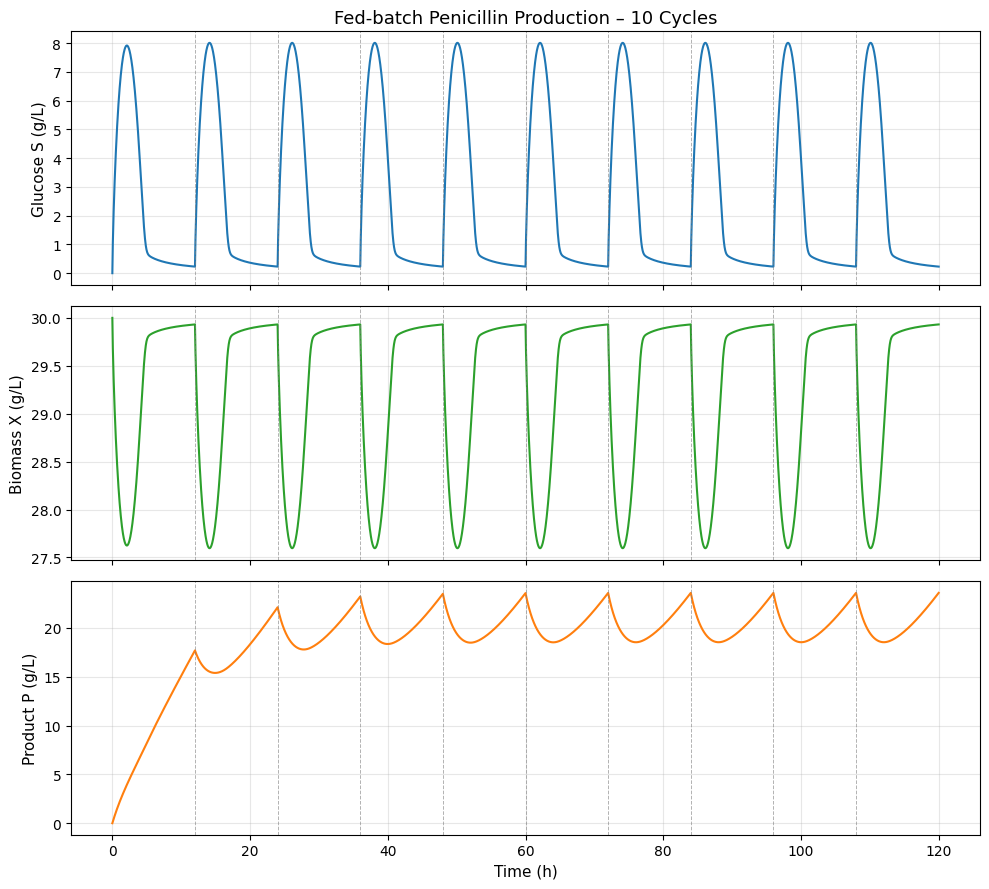

In [6]:
y_init = [S0_ic, X0, P0_ic, V0]

all_t  = []
all_S  = []
all_X  = []
all_P  = []
all_V  = []

total_product_removed = 0.0   
t_offset = 0.0

for cycle in range(n_cycles):
    t_span = (0, t_cycle)
    t_eval = np.linspace(0, t_cycle, 500)

    sol = solve_ivp(fed_batch_odes, t_span, y_init,
                    method='RK45', t_eval=t_eval,
                    rtol=1e-8, atol=1e-10)

    S_sol, X_sol, P_sol, V_sol = sol.y

  
    all_t.append(sol.t + t_offset)
    all_S.append(S_sol)
    all_X.append(X_sol)
    all_P.append(P_sol)
    all_V.append(V_sol)

    
    P_end = P_sol[-1]
    V_end = V_sol[-1]
    mass_P_removed = P_end * V_rem   
    total_product_removed += mass_P_removed

    
    S_new = S_sol[-1]
    X_new = X_sol[-1]
    P_new = P_sol[-1]
    V_new = V_end - V_rem            

    y_init    = [S_new, X_new, P_new, V_new]
    t_offset += t_cycle

print(f"\nPart (c): Total product removed over {n_cycles} cycles = "
      f"{total_product_removed/1000:.4f} kg  ({total_product_removed:.1f} g)")


t_all = np.concatenate(all_t)
S_all = np.concatenate(all_S)
X_all = np.concatenate(all_X)
P_all = np.concatenate(all_P)
V_all = np.concatenate(all_V)


fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(t_all, S_all, color='tab:blue')
axes[0].set_ylabel('Glucose S (g/L)', fontsize=11)
axes[0].set_title('Fed-batch Penicillin Production – 10 Cycles', fontsize=13)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_all, X_all, color='tab:green')
axes[1].set_ylabel('Biomass X (g/L)', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_all, P_all, color='tab:orange')
axes[2].set_ylabel('Product P (g/L)', fontsize=11)
axes[2].set_xlabel('Time (h)', fontsize=11)
axes[2].grid(True, alpha=0.3)


for ax in axes:
    for c in range(1, n_cycles):
        ax.axvline(c * t_cycle, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)

plt.tight_layout()
#plt.savefig(r'C:\Users\ferra\Desktop\Secret Sauce\PassMergue\semestre 2\Bio_react\project_3\ex2_part_c.png', dpi=150)
plt.show()
plt.close()

d) Substrate inhibition

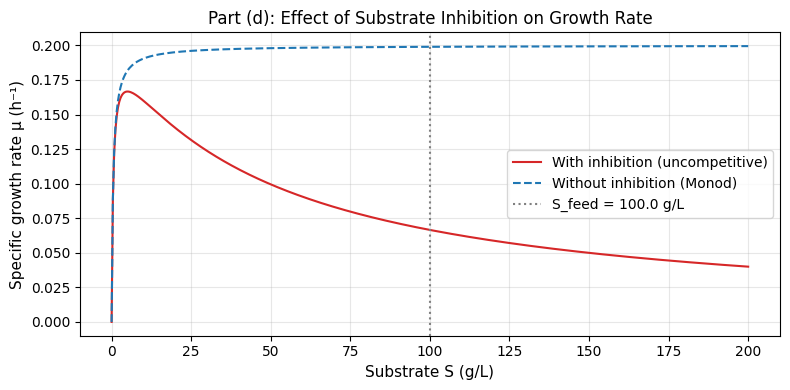


Part (d): μ at S_feed=100.0 g/L WITH inhibition    = 0.0666 h-1
Part (d): μ at S_feed=100.0 g/L WITHOUT inhibition = 0.1990 h-1
          Reduction due to inhibition: 66.6%


In [7]:
def mu_no_inhib(S):
    return mu_m * S / (Ks + S)

S_range = np.linspace(0, 200, 500)
mu_inh  = [mu(s) for s in S_range]
mu_noi  = [mu_no_inhib(s) for s in S_range]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(S_range, mu_inh, label='With inhibition (uncompetitive)', color='tab:red')
ax.plot(S_range, mu_noi, label='Without inhibition (Monod)', color='tab:blue', linestyle='--')
ax.set_xlabel('Substrate S (g/L)', fontsize=11)
ax.set_ylabel('Specific growth rate μ (h⁻¹)', fontsize=11)
ax.set_title('Part (d): Effect of Substrate Inhibition on Growth Rate', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3)

ax.axvline(S_feed, color='gray', linestyle=':', label=f'S_feed = {S_feed} g/L')
ax.legend()
plt.tight_layout()
#plt.savefig(r'C:\Users\ferra\Desktop\Secret Sauce\PassMergue\semestre 2\Bio_react\project_3\ex2_part_d.png', dpi=150)
plt.show()
plt.close()

mu_at_Sfeed_inh = mu(S_feed)
mu_at_Sfeed_noi = mu_no_inhib(S_feed)
print(f"\nPart (d): μ at S_feed={S_feed} g/L WITH inhibition    = {mu_at_Sfeed_inh:.4f} h-1")
print(f"Part (d): μ at S_feed={S_feed} g/L WITHOUT inhibition = {mu_at_Sfeed_noi:.4f} h-1")
print(f"          Reduction due to inhibition: {(1 - mu_at_Sfeed_inh/mu_at_Sfeed_noi)*100:.1f}%")

f) Cycle optimisation

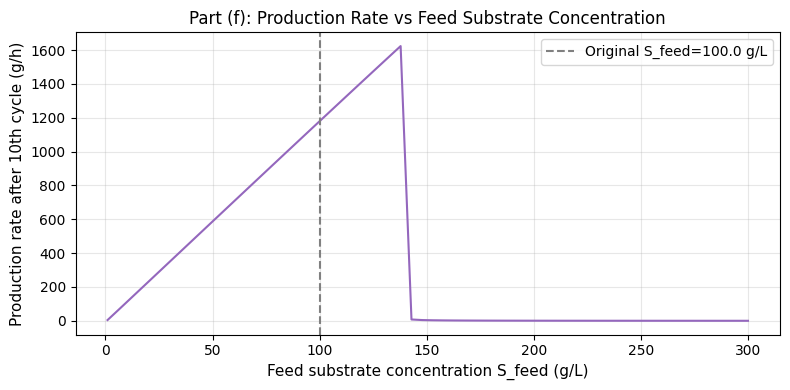


Part (f): Optimal S_feed = 137.8 g/L  -> max production rate = 1624.18 g/h


In [8]:
S_feed_range = np.linspace(1, 300, 60)
prod_rates   = []

for Sf in S_feed_range:
    y_loc = [0.0, X0, 0.0, V0]
    
    def make_odes(Sf_val):
        def odes_loc(t, y):
            S, X, P, V = y
            S = max(S, 0.0); X = max(X, 0.0); P = max(P, 0.0)
            D = f0 / V
            mu_v = mu_m * S / (Ks + S * (1 + S / Ki))
            return [D*(Sf_val - S) - (mu_v/Yxs)*X,
                    mu_v*X - D*X,
                    qp*X - D*P,
                    f0]
        return odes_loc

    for cyc in range(n_cycles):
        sol_loc = solve_ivp(make_odes(Sf), (0, t_cycle), y_loc,
                            method='RK45', t_eval=[t_cycle],
                            rtol=1e-8, atol=1e-10)
        S_e, X_e, P_e, V_e = sol_loc.y[:, -1]
        if cyc < n_cycles - 1:
            y_loc = [S_e, X_e, P_e, V_e - V_rem]
        else:
            prod_rate = (P_e * V_rem) / t_cycle  # g/h

    prod_rates.append(prod_rate)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(S_feed_range, prod_rates, color='tab:purple')
ax.set_xlabel('Feed substrate concentration S_feed (g/L)', fontsize=11)
ax.set_ylabel('Production rate after 10th cycle (g/h)', fontsize=11)
ax.set_title('Part (f): Production Rate vs Feed Substrate Concentration', fontsize=12)
ax.axvline(S_feed, color='gray', linestyle='--', label=f'Original S_feed={S_feed} g/L')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig(r'C:\Users\ferra\Desktop\Secret Sauce\PassMergue\semestre 2\Bio_react\project_3\ex2_part_f.png', dpi=150)
plt.show()
plt.close()

opt_idx = np.argmax(prod_rates)
print(f"\nPart (f): Optimal S_feed = {S_feed_range[opt_idx]:.1f} g/L  "
      f"-> max production rate = {prod_rates[opt_idx]:.2f} g/h")